In [1]:
!pip install torchsummary

In [ ]:
!pip install torch_tensorrt

In [ ]:
import os
os.environ['CUDA_LAUNCH_BLOCKING'] = "1"
import time
import numpy as np
import glob
from matplotlib import pyplot as plt
from tqdm.notebook import tqdm
# import ignite
import torch
from torch import nn
from torch import optim
from torch.nn import functional as F
from torch.utils.data import Dataset, DataLoader
# import torch_tensorrt
import torchvision as tv
import torchvision.transforms.v2 as tr
from torchmetrics.image import PeakSignalNoiseRatio as PSNR, StructuralSimilarityIndexMeasure as SSIM
from torchsummary import summary

import torch.multiprocessing as mp
from torch.nn.parallel import DistributedDataParallel as DDP
from torch.utils.data.distributed import (
    DistributedSampler,
)  # Distribute data across multiple gpus
from torch.distributed import init_process_group, destroy_process_group
torch.backends.cuda.matmul.allow_tf32 = True


In [3]:
# torch.multiprocessing.set_start_method('spawn', force=True)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# torch.set_default_device(device)
print(device)

cuda


In [4]:
LR_IMG_SIZE = (96,96)
HR_IMG_SIZE = (384,384)
CHANNELS_NUM = 3
BATCH_SIZE_PER_REPLICA = 32
# GLOBAL_BATCH_SIZE = BATCH_SIZE_PER_REPLICA * strategy.num_replicas_in_sync
GLOBAL_BATCH_SIZE = BATCH_SIZE_PER_REPLICA

In [5]:
class CustomDataset(Dataset):
    def __init__(self, file_names, transform, target_transform):
        self.file_names = file_names
        self.transform = transform
        self.target_transform = target_transform

    def __len__(self):
        return len(self.file_names)

    def __getitem__(self, idx):
        if torch.is_tensor(idx):
            idx = idx.tolist()

        label = tv.io.read_image(self.file_names[idx])

        if self.target_transform:
            label = self.target_transform(label)

        if self.transform:
            image = self.transform(label)

        return image, label

def create_dataloader(img_filenames, transform = None, target_transform = None,
                      batch_size=12, shuffle=True, use_sampler = False, num_workers=2):
    dataset = CustomDataset(img_filenames, transform, target_transform)
    if use_sampler:
        shuffle = False
        sampler = DistributedSampler(dataset)
    else:
        sampler = None

    dataloader = DataLoader(dataset, batch_size = batch_size, shuffle = shuffle, sampler = sampler,
                            pin_memory = True, num_workers = num_workers,
                            drop_last=True, generator=torch.Generator(device='cpu'))
    return dataloader

In [6]:
target_transform = tr.Compose([tr.RandomCrop(HR_IMG_SIZE),
                               tr.RandomHorizontalFlip(p=0.5),
                               tr.ToDtype(torch.float32, scale=True),
                               tr.Normalize(mean = [0.5 for _ in range(CHANNELS_NUM)],
                                            std = [0.5 for _ in range(CHANNELS_NUM)])
                              ])

transform = tr.Compose([tr.Resize(LR_IMG_SIZE, antialias=True)])


val_target_transform = tr.Compose([tr.Resize(HR_IMG_SIZE, antialias=True),
                                   tr.ToDtype(torch.float32, scale=True),
                                   tr.Normalize(mean = [0.5 for _ in range(CHANNELS_NUM)],
                                                std = [0.5 for _ in range(CHANNELS_NUM)])
                                  ])

val_transform = tr.Compose([tr.Resize(LR_IMG_SIZE, antialias=True)])

In [7]:
hr_train_filenames = glob.glob('/kaggle/input/my-div2k-dataset/DIV2K_train_HR/*.png')
hr_val_filenames = glob.glob('/kaggle/input/my-div2k-dataset/DIV2K_valid_HR/*.png')
print(len(hr_train_filenames))
print(len(hr_val_filenames))
BATCH_SIZE = 16
USE_SAMPLER = True
train_dataloader = create_dataloader(hr_train_filenames, transform, target_transform,
                                     batch_size = BATCH_SIZE, shuffle = True, num_workers = 4)
val_dataloader = create_dataloader(hr_val_filenames, val_transform, val_target_transform,
                                   batch_size = 16, shuffle = False, use_sampler = USE_SAMPLER, num_workers = 4)

800
100


Feature batch shape: torch.Size([24, 3, 96, 96])
Labels batch shape: torch.Size([24, 3, 384, 384])


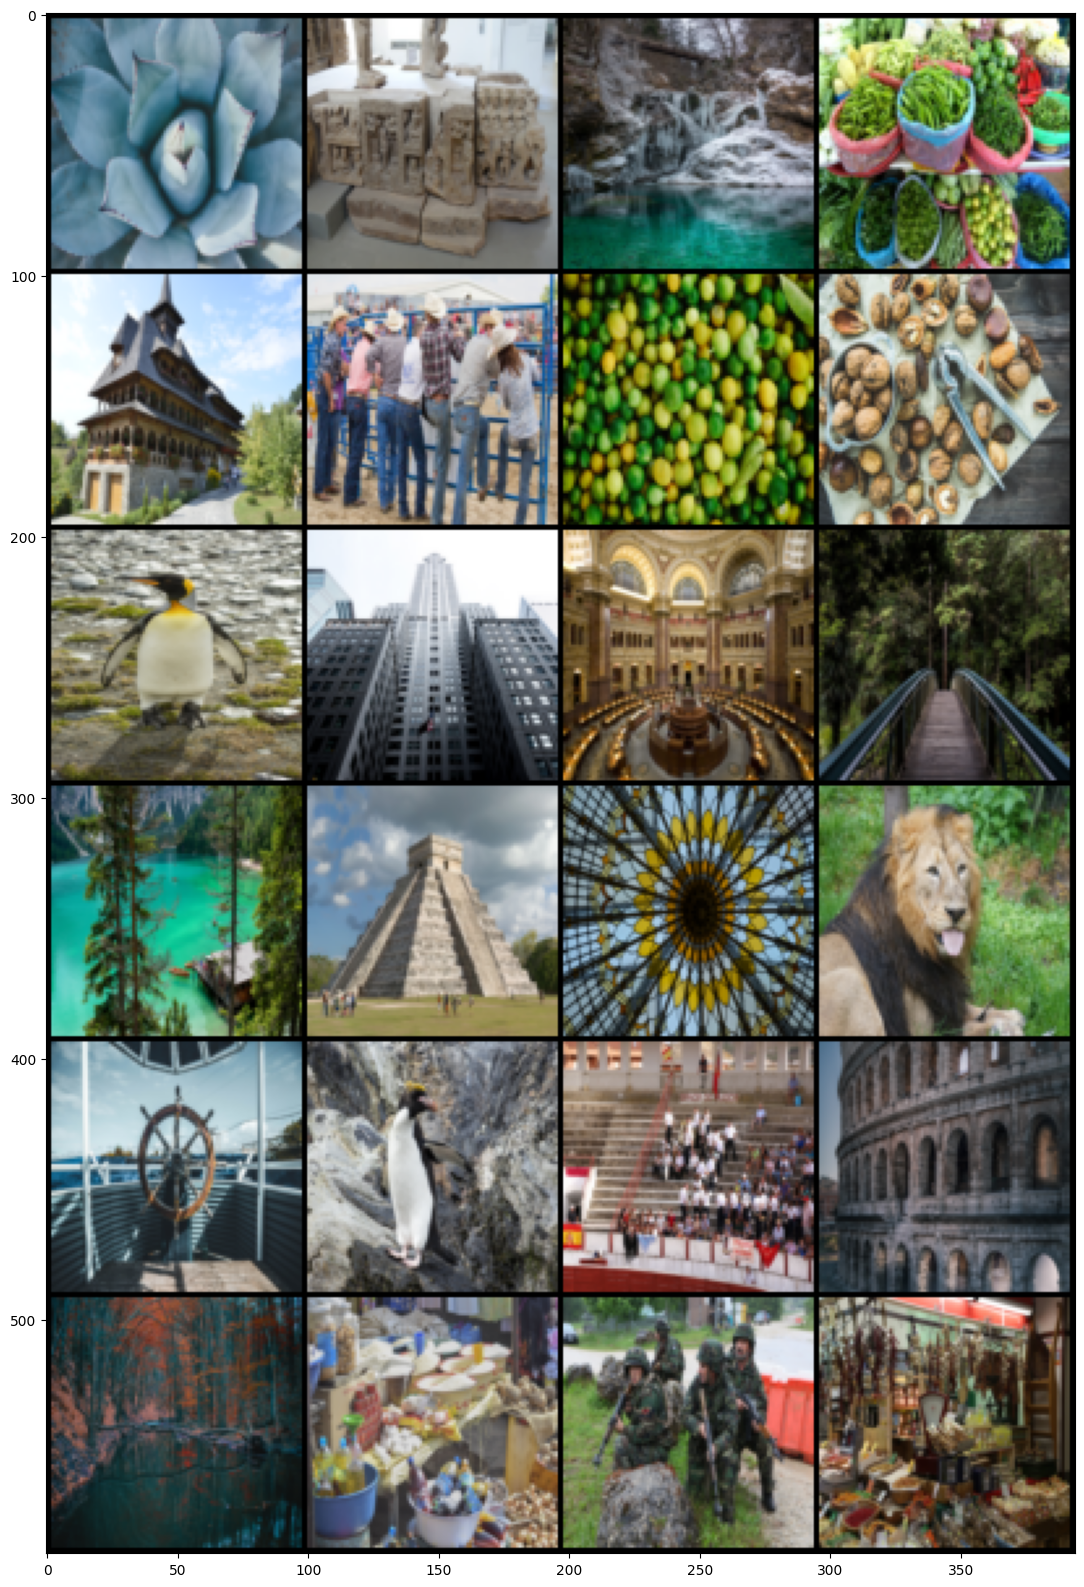

In [8]:
# Display image and label.
# if __name__ == '__main__':
# x = iter(val_dataloader)
# print(dir(x))
# train_features, train_labels = next(x)
train_features, train_labels = next(iter(val_dataloader))
print(f"Feature batch shape: {train_features.size()}")
print(f"Labels batch shape: {train_labels.size()}")
plt.figure(figsize=[20, 20])
out = tv.utils.make_grid(((train_features + 1) * 127.5).type(torch.uint8), nrow=4).permute(1, 2, 0)
plt.imshow(out)
plt.show()

In [8]:
from torchvision.models.vgg import vgg19
vgg = vgg19(weights = tv.models.VGG19_Weights.DEFAULT)
vgg = nn.Sequential(*list(vgg.features)[:31]).eval()
for param in vgg.parameters():
    param.requires_grad = False
vgg = vgg.to(device)

Downloading: "https://download.pytorch.org/models/vgg19-dcbb9e9d.pth" to /root/.cache/torch/hub/checkpoints/vgg19-dcbb9e9d.pth
100%|██████████| 548M/548M [00:04<00:00, 144MB/s]  


In [9]:
# summary(vgg, (3,96,96))

In [10]:
def init_loss_fn(g_model, loss_fn, lr, hr):
    hr_fake = g_model(lr)
    return loss_fn(hr_fake, hr)

def _adversarial_loss(d_model, loss_object, hr_fake):
    y_discrim_logits = d_model(hr_fake.detach())
#     print(y_discrim_logits[0].shape)
    return loss_object(y_discrim_logits[0], torch.ones_like(y_discrim_logits[0]))

def renormalize_vgg(x):

    re_normalize = tr.Compose([tr.Normalize(mean=[-1 for _ in range(CHANNELS_NUM)], # invert norm
                                            std=[2 for _ in range(CHANNELS_NUM)]),
                                tr.Normalize(mean = [ 0.485, 0.456, 0.406 ], # renorm
                                             std = [ 0.229, 0.224, 0.225 ])]
                             )
    return re_normalize(x)

def gen_loss_fn(d_model, loss_fn1=torch.nn.BCEWithLogitsLoss(), loss_fn2=torch.nn.MSELoss(), hr=None, hr_fake=None):
    with torch.no_grad():
        feature_fake = vgg(renormalize_vgg(hr_fake)) / 12.75
        feature_real = vgg(renormalize_vgg(hr)) / 12.75
    g_gan_loss = 1e-3 * _adversarial_loss(d_model, loss_fn1, hr_fake) # adversarial loss
    mse_loss = loss_fn2(hr_fake, hr) # content loss
    vgg_loss = loss_fn2(feature_fake, feature_real) # content loss
    return mse_loss, g_gan_loss, vgg_loss

def disc_loss_fn(loss_object=torch.nn.BCEWithLogitsLoss(), y_real_pred_logits=None, y_fake_pred_logits=None):
    loss_real = loss_object(y_real_pred_logits, torch.ones_like(y_real_pred_logits))
    loss_fake = loss_object(y_fake_pred_logits, torch.zeros_like(y_fake_pred_logits))
    return loss_real + loss_fake

In [11]:
class Generator_2(nn.Module):
    def __init__(self, num_blocks=16):
        super(Generator_2, self).__init__()
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=64, kernel_size=3, stride=1, padding=1)
        self.relu = nn.ReLU()

        self.residual_blocks = nn.Sequential(*[ResidualBlock() for _ in range(num_blocks)])

        self.conv2 = nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(64)

        self.conv3 = nn.Conv2d(in_channels=64, out_channels=256, kernel_size=3, stride=1, padding=1)
        self.subpixel1 = nn.PixelShuffle(upscale_factor=2)
        self.relu1 = nn.ReLU()

        self.conv4 = nn.Conv2d(in_channels=64, out_channels=256, kernel_size=3, stride=1, padding=1)
        self.subpixel2 = nn.PixelShuffle(upscale_factor=2)
        self.relu2 = nn.ReLU()

        self.conv5 = nn.Conv2d(in_channels=64, out_channels=3, kernel_size=1, stride=1, padding=0)

    def forward(self, x):
        x = self.relu(self.conv1(x))
        temp = x

        x = self.residual_blocks(x)
        x = self.bn1(self.conv2(x))
        x = x + temp

        x = self.relu1(self.subpixel1(self.conv3(x)))
        x = self.relu2(self.subpixel2(self.conv4(x)))

        x = torch.tanh(self.conv5(x))
        return x

class ResidualBlock(nn.Module):
    def __init__(self):
        super(ResidualBlock, self).__init__()
        self.conv1 = nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, stride=1, padding=1)
        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU()
        self.conv2 = nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, stride=1, padding=1)
        self.bn2 = nn.BatchNorm2d(64)

    def forward(self, x):
        z = self.relu(self.bn1(self.conv1(x)))
        z = self.bn2(self.conv2(z))
        x = x + z
        return x

class Discriminator_2(nn.Module):
    def __init__(self):
        super(Discriminator_2, self).__init__()
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=64, kernel_size=3, stride=1, padding=1)
        self.leaky1 = nn.LeakyReLU(negative_slope=0.2)

        self.convblock = nn.Sequential(
            ConvolutionBlock(64,64, 3, 2),
            ConvolutionBlock(64, 128, 3, 2),
            ConvolutionBlock(128, 128, 3, 2),
            ConvolutionBlock(128, 256, 3, 2),
            ConvolutionBlock(256, 256, 3, 2),
            ConvolutionBlock(256, 512, 3, 1),
            ConvolutionBlock(512, 512, 3, 1)
        )

        self.flatten = nn.Flatten()
        self.Dense1 = nn.Linear(512 * 12 * 12, 256)
        self.leaky2 = nn.LeakyReLU(negative_slope=0.2)
        self.Dense2 = nn.Linear(256, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.leaky1(self.conv1(x))
        x = self.convblock(x)
        x = self.flatten(x)
        x = self.leaky2(self.Dense1(x))
        logits = self.Dense2(x)
        n = self.sigmoid(logits)
        return n, logits

class ConvolutionBlock(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size, strides):
        super(ConvolutionBlock, self).__init__()
        self.conv = nn.Conv2d(in_channels=in_channels, out_channels=out_channels, kernel_size=kernel_size, stride=strides, padding=1)
        self.batch_norm = nn.BatchNorm2d(out_channels)
        self.leaky_relu = nn.LeakyReLU(negative_slope=0.2)

    def forward(self, x):
        x = self.leaky_relu(self.batch_norm(self.conv(x)))
        return x

In [12]:
# model = Generator_2().to(device)
# summary(model, (3,96, 96))

In [13]:
# model = Discriminator_2().to(device)
# summary(model, (3,384, 384))

In [14]:
class SRGAN(nn.Module):
    def __init__(self, generator, discriminator, generator_loss, discriminator_loss):
        super(SRGAN, self).__init__()
        self.generator = generator
        self.discriminator = discriminator
        self.generator_loss = generator_loss
        self.discriminator_loss = discriminator_loss
        self.loss_fn1 = nn.BCEWithLogitsLoss()
        self.loss_fn2 = nn.MSELoss()
        self.psnr_metric = PSNR(data_range = 2)
        self.ssim_metric = SSIM(data_range = 2)

    def forward(self, x):
        return self.generator(x)

    def train_step(self, lr, hr, g_optimizer, d_optimizer):
        self.generator.train()
        self.discriminator.train()

        # Generator
        fake_hr = self.generator(lr)
        mse_loss, g_gan_loss, vgg_loss = self.generator_loss(self.discriminator, self.loss_fn1, self.loss_fn2, hr, fake_hr)
        g_loss = mse_loss + g_gan_loss + vgg_loss

        g_optimizer.zero_grad()
        g_loss.backward()
        g_optimizer.step()

        # Discriminator
        d_hr_pred, d_hr_pred_logits = self.discriminator(hr)
        d_hr_fake_pred, d_hr_fake_pred_logits = self.discriminator(fake_hr.detach())  # Detach to prevent gradients from flowing back

        d_loss = self.discriminator_loss(self.loss_fn1, d_hr_pred_logits, d_hr_fake_pred_logits)

        d_optimizer.zero_grad()
        d_loss.backward()
        d_optimizer.step()

        # PSNR and SSIM will act as a loss function and will contain the gradient graphs that can make some error as OOM
        # so we need detach fake_hr or use no_grad to ignore gradient
        with torch.no_grad():
            psnr = self.psnr_metric(hr, fake_hr)
            ssim = self.ssim_metric(hr, fake_hr)

        return torch.stack([g_loss, d_loss, mse_loss, g_gan_loss, vgg_loss, psnr, ssim])

def train_epoch(srgan, train_dataloader, g_optimizer, d_optimizer, device):
    srgan.train()
    loss = torch.tensor([0.0] * 7, device = device)
    for idx, (lr, hr) in enumerate(train_dataloader):
        lr = lr.to(device)
        hr = hr.to(device)

        loss += srgan.train_step(lr, hr, g_optimizer, d_optimizer)

    loss = loss / len(train_dataloader)

    return loss

def test_epoch(gen, dataloader):
    gen.eval()
    with torch.no_grad():
        lr_val_samples, hr_val_samples = next(iter(dataloader))

        fig, ax = plt.subplots(3,3, figsize=(14,14))

        for i in range(3):
            ax[i,0].imshow(((lr_val_samples[i].permute(1, 2, 0)+1)*127.5).type(torch.uint8))
            ax[i,1].imshow(((gen(lr_val_samples.to(device))[i].cpu()+1)*127.5).type(torch.uint8).permute(1, 2, 0))
            ax[i,2].imshow(((hr_val_samples[i].permute(1, 2, 0)+1)*127.5).type(torch.uint8))
            ax[i,0].set_yticklabels([])
            ax[i,1].set_yticklabels([])
            ax[i,2].set_yticklabels([])
        plt.subplots_adjust(wspace=0.05, hspace=0.05)
        plt.show()

# torch._dynamo.list_backends()
# ['cudagraphs', 'inductor', 'onnxrt', 'openxla', 'openxla_eval', 'tvm']
# torch.compile(model, backend="torch_tensorrt")
from torch._dynamo.backends.common import aot_autograd
from functorch.compile import make_boxed_func

def my_compiler(gm, example_inputs):
    return make_boxed_func(gm.forward)

my_backend = aot_autograd(fw_compiler=my_compiler)  # bw_compiler=my_compiler

generator = Generator_2()
generator = torch.compile(generator, fullgraph=True, backend = my_backend).to(device)
discriminator = Discriminator_2()
discriminator = torch.compile(discriminator, fullgraph=True, backend = my_backend).to(device)
srgan = SRGAN(generator, discriminator, gen_loss_fn, disc_loss_fn)
srgan = torch.compile(srgan, fullgraph=True, backend = my_backend).to(device)

g_optimizer = optim.Adam(generator.parameters(), lr=0.0002, betas=(0.5, 0.999))
d_optimizer = optim.Adam(discriminator.parameters(), lr=0.0002, betas=(0.5, 0.999))

Epoch [1/5]
ETA: 59.0s d_loss: 0.205340, g_loss: 0.671333, mse_loss: 0.089867, g_gan_loss: 0.000655, vgg_loss: 0.114818, psnr: 17.625126, ssim: 0.356185
Epoch [2/5]
ETA: 47.0s d_loss: 0.143340, g_loss: 0.907145, mse_loss: 0.039560, g_gan_loss: 0.000635, vgg_loss: 0.103146, psnr: 20.161688, ssim: 0.504823
Epoch [3/5]
ETA: 47.0s d_loss: 0.131208, g_loss: 0.013622, mse_loss: 0.031344, g_gan_loss: 0.000691, vgg_loss: 0.099173, psnr: 21.166712, ssim: 0.545944
Epoch [4/5]
ETA: 47.0s d_loss: 0.120512, g_loss: 0.047818, mse_loss: 0.027464, g_gan_loss: 0.000689, vgg_loss: 0.092360, psnr: 21.784088, ssim: 0.583287
Epoch [5/5]
ETA: 48.0s d_loss: 0.112038, g_loss: 0.100595, mse_loss: 0.023587, g_gan_loss: 0.000686, vgg_loss: 0.087765, psnr: 22.378862, ssim: 0.612370


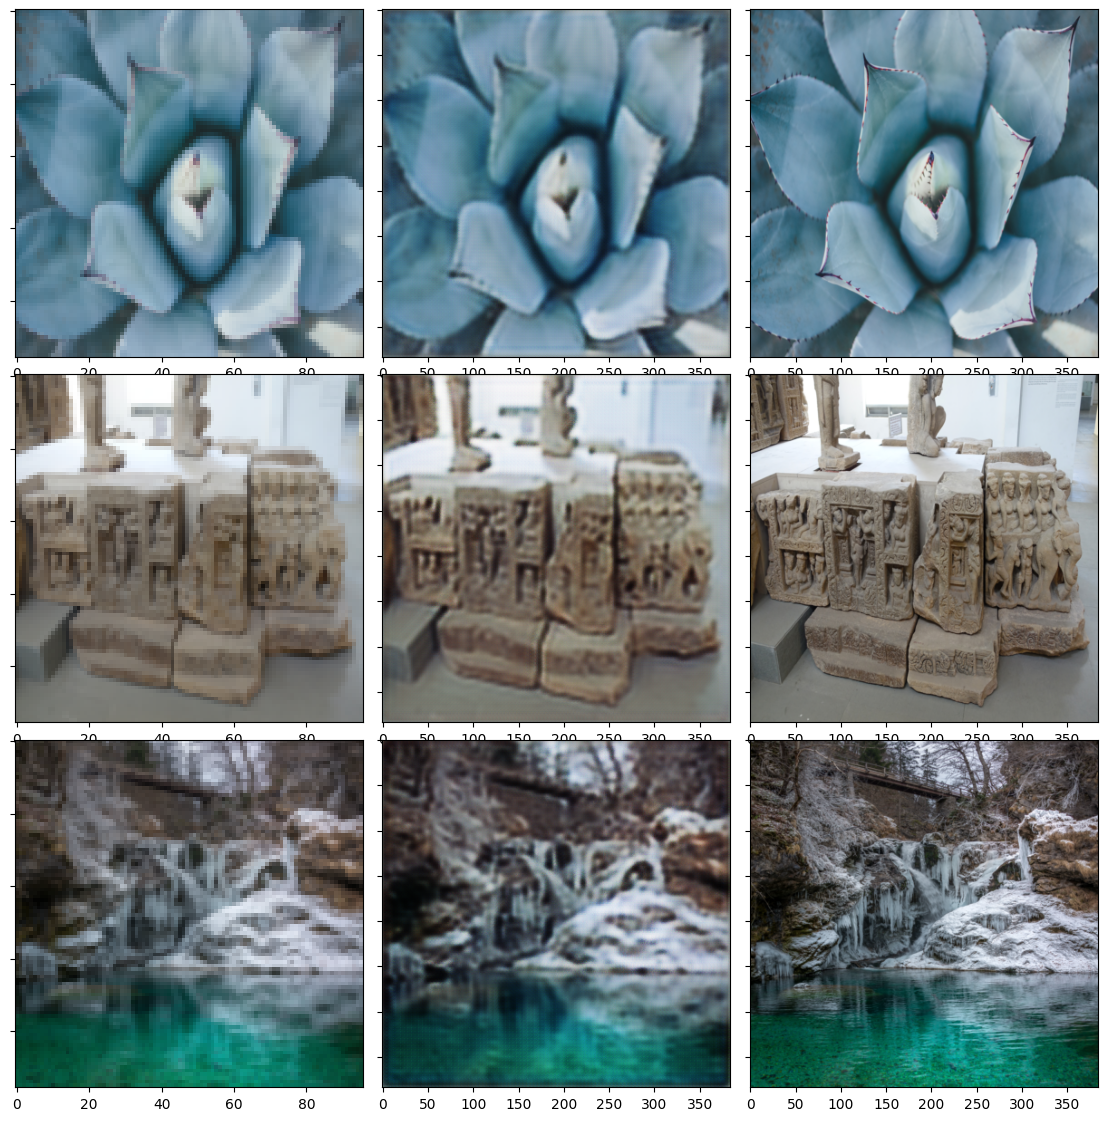

In [17]:
metric_names = ['d_loss', 'g_loss', 'mse_loss', 'g_gan_loss', 'vgg_loss', 'psnr', 'ssim']

num_epochs = 5
for epoch in range(num_epochs):
    start_time = time.time()
    print(f"Epoch [{epoch+1}/{num_epochs}]")
    loss = train_epoch(srgan, train_dataloader, g_optimizer, d_optimizer, device)
    print(f"ETA: {np.round(time.time() - start_time)}s {', '.join([f'{metric_name}: {value:.6f}' for metric_name, value in zip(metric_names, loss)])}")
    if (epoch +1) % 5 == 0:
        test_epoch(generator, val_dataloader)